# Plotting the resonance wavefunction with and without CS and EC
This notebook is here to help visualize what goes wrong when trying to see the resonance without complex scaling (it's impossible
using bound-state techniques like finite-volume box normalization).

In [12]:
from src.dvr import *
from src.ec import ECSystem

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
save_plots = True
plots_folder = Path("./plots/plot_resonance")
plots_folder.mkdir(exist_ok=True, parents=True)

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [3]:
x_plot = np.linspace(0.0, L, 500)

## Resonance wavefunction without CS or EC
Attempting to plot the resonance and compute its observables without CS or EC. It's impossible since the resonance is
not in the span of the box-normalization states (it can't be). The energy is only close because the resonance is very
narrow (small imaginary component), so there exists a box state that happens to have a real energy near it.

In [4]:
test_system = DVR(n, L, rotation_angle=0.0, potential=gauss_s)
eigval, eigstate = test_system.closest_to_resonance(real_res)
rr = test_system.compute_rr(eigstate[:, 0], rotate_rr=False, regulator=False)
eigval = eigval[0]

resonance = test_system.DVR_to_position_space(eigstate[:, 0], x_plot)

print("Energy and radius of resonance without complex scaling:")
print(f"\tE = {np.real(eigval):.3f} + j{np.imag(eigval):.3f}")
print(f"\t<r^2> = {np.real(rr):.3f} + j{np.imag(rr):.3f}")

Energy and radius of resonance without complex scaling:
	E = 1.590 + j0.000
	<r^2> = 108.661 + j0.000


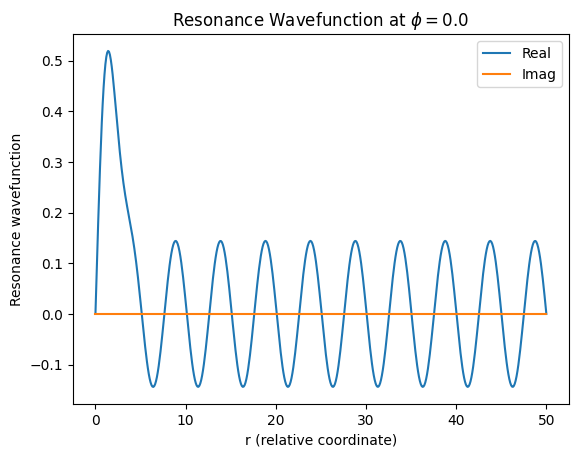

In [5]:
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(resonance), label='Real')
ax.plot(x_plot, np.imag(resonance), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Resonance Wavefunction at $\phi=0.0$")
ax.legend()
if save_plots:
    plt.savefig(plots_folder / "resonance_wavefunc_nocs.png")
plt.show()

## Resonance wavefunction at $\phi=\pi/24$ without EC
Here, we plot the complex-scaled resonance and compute it's observables. Under complex-scaling, the
resonance becomes normalizable, so the box states can represent it.

In [6]:
test_system = DVR(n, L, rotation_angle=pi/24, potential=gauss_s)
eigval, eigstate = test_system.closest_to_resonance(real_res)
rr = test_system.compute_rr(eigstate[:, 0], rotate_rr=True, regulator=False)
eigval = eigval[0]

resonance = test_system.DVR_to_position_space(eigstate[:, 0], x_plot)

print("Energy and radius of resonance with complex scaling at phi=pi/24")
print(f"\tE = {np.real(eigval):.3f} + j{np.imag(eigval):.3f}")
print(f"\t<r^2> = {np.real(rr):.3f} + j{np.imag(rr):.3f}")

Energy and radius of resonance with complex scaling at phi=pi/24
	E = 1.606 + j-0.047
	<r^2> = 0.774 + j0.200


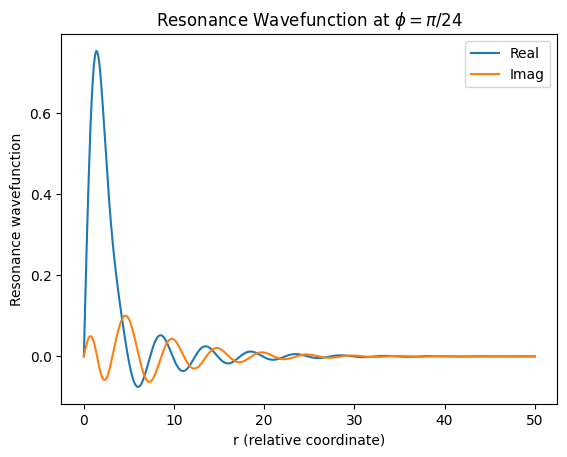

In [7]:
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(resonance), label='Real')
ax.plot(x_plot, np.imag(resonance), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Resonance Wavefunction at $\phi=\pi/24$")
ax.legend()
if save_plots:
    plt.savefig(plots_folder / "resonance_wavefunc_cs.png")
plt.show()

### Resonance wavefunction at multiple $\phi$
Here, we plot the complex-scaled resonance wavefunction at multiple values of the complex-scaling rotation angle.

In [8]:
# plot CS resonance for multiple phi
phis = np.linspace(0.1, 0.5, 50)
res_states = []
energies = []
for phi in phis:
    test_system.reset_rotation_angle(phi)
    eigval, eigstate = test_system.closest_to_resonance(real_res)
    energies.append(eigval[0])
    res_states.append(eigstate)

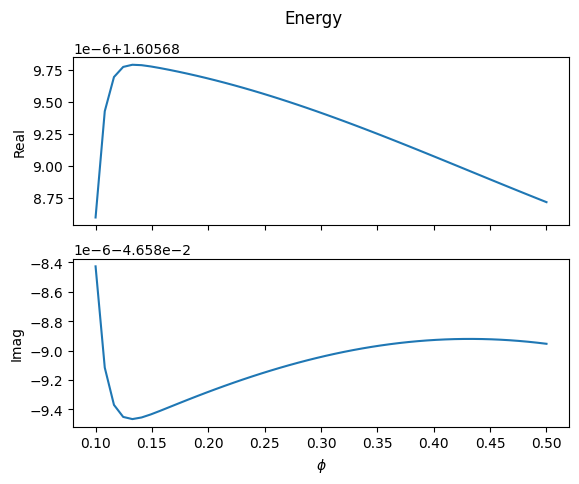

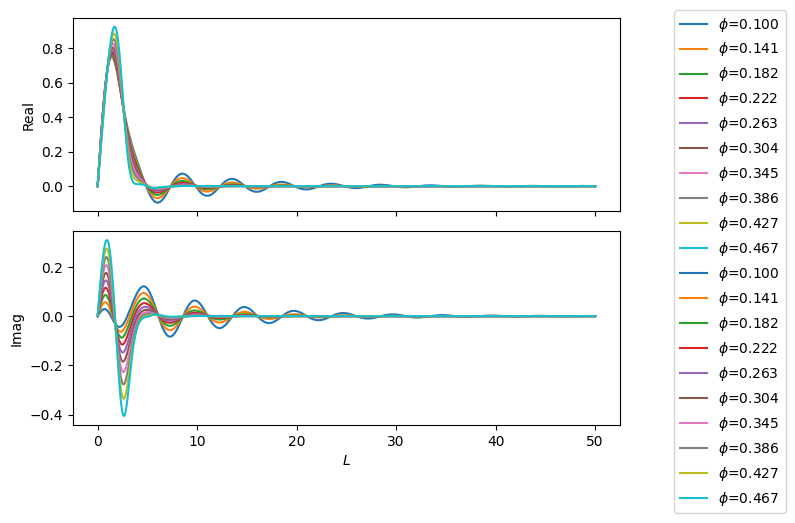

In [9]:
# plot the energy as a function of phi
fig, [ax1, ax2] = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies), label="Real")
ax2.plot(phis, np.imag(energies), label="Imag")
ax2.set_xlabel(r"$\phi$")
fig.suptitle("Energy")
ax1.set_ylabel("Real")
ax2.set_ylabel("Imag")
plt.show()

# plot the resonance wavefunctions as a function of phi
x_plot = np.linspace(0, L, 1000)
fig, ax = plt.subplots(2, 1, sharex=True)
for phi, res in zip(phis[::5],res_states[::5]):
    wavefunc = test_system.DVR_to_position_space(res, x_plot)
    ax[0].plot(x_plot, np.real(wavefunc), label=fr'$\phi$={phi:.3f}')
    ax[1].plot(x_plot, np.imag(wavefunc), label=fr'$\phi$={phi:.3f}')
    ax[1].set_xlabel(r"$L$")
    ax[0].set_ylabel("Real")
    ax[1].set_ylabel("Imag")
fig.legend(loc='upper left', bbox_to_anchor=(1.05,1.0))
plt.tight_layout()
plt.show()

## Resonance wavefunction at $\phi=0.0$ with EC back-rotation
Here, we plot the EC back-rotated resonance at $\phi=0.0$.

In [13]:
phi_train = np.linspace(pi/24, pi/6, 50)

test_EC = ECSystem(test_system, real_res)
test_EC.train(phi_train)
test_EC.construct_basis()

phip = 0.0
predict_energy, predict_rr = test_EC.predict_energies_rrs([phip], rotate_rr=False)

_, resonance_DVR = test_EC.predict_DVR_state_at(phip)
resonance = test_EC.system.DVR_to_position_space(resonance_DVR, x_plot)

print("Energy and radius of resonance at phi=0.0 using EC:")
print(f"\tE = {np.real(predict_energy[0]):.3f} + j{np.imag(predict_energy[0]):.3f}")
print(f"\t<r^2> = {np.real(predict_rr[0]):.3f} + j{np.imag(predict_rr[0]):.3f}")

Energy and radius of resonance at phi=0.0 using EC:
	E = 1.606 + j-0.047
	<r^2> = 0.775 + j0.193


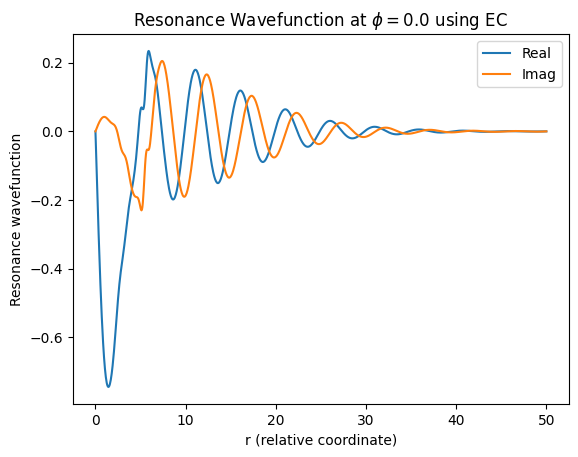

In [14]:
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(resonance), label='Real')
ax.plot(x_plot, np.imag(resonance), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Resonance Wavefunction at $\phi=0.0$ using EC")
ax.legend()
if save_plots:
    plt.savefig(plots_folder / "resonance_wavefunc_ec.png")
plt.show()